<a href="https://colab.research.google.com/github/hasan2733/artificial-intelligence/blob/main/Notebooks/DL/RNN/RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

df = pd.read_csv(url)
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [12]:
data = df['Passengers'].values.reshape(-1,1)
data[0:5]

array([[112],
       [118],
       [132],
       [129],
       [121]])

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data = scaler.fit_transform(data)
data[0:5]

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853]])

In [14]:
data.shape

(144, 1)

In [15]:
def create_sample(data, month = 12):
  X,y = [],[]
  for i in range(len(data)-month):
    X.append(data[i:i+month])
    y.append(data[i+month])
  return np.array(X),np.array(y)

x,y = create_sample(data)
x.shape, y.shape

((132, 12, 1), (132, 1))

In [16]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
#Simple RNN implementation

rnn = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(50,activation="tanh",input_shape=(12,1)),
    tf.keras.layers.Dense(1)
])

rnn.compile(optimizer="adam",loss="mse")

In [21]:
rnn.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test))

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0284 - val_loss: 0.0157
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0103 - val_loss: 0.0096
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0117 - val_loss: 0.0048
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0042 - val_loss: 0.0058
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0069 - val_loss: 0.0032
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0049 - val_loss: 0.0020
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0027 - val_loss: 0.0033
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0024 - val_loss: 0.0014
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0020 - val_l

In [22]:
pred = rnn.predict(x_test)
pred = scaler.inverse_transform(pred)
y_test = scaler.inverse_transform(y_test)

print(pred[0:5])
print(y_test[0:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
[[272.67386]
 [308.3741 ]
 [194.59007]
 [225.50996]
 [314.01312]]
[[259.]
 [306.]
 [199.]
 [242.]
 [318.]]


### Visualize Predictions vs. Actual Values

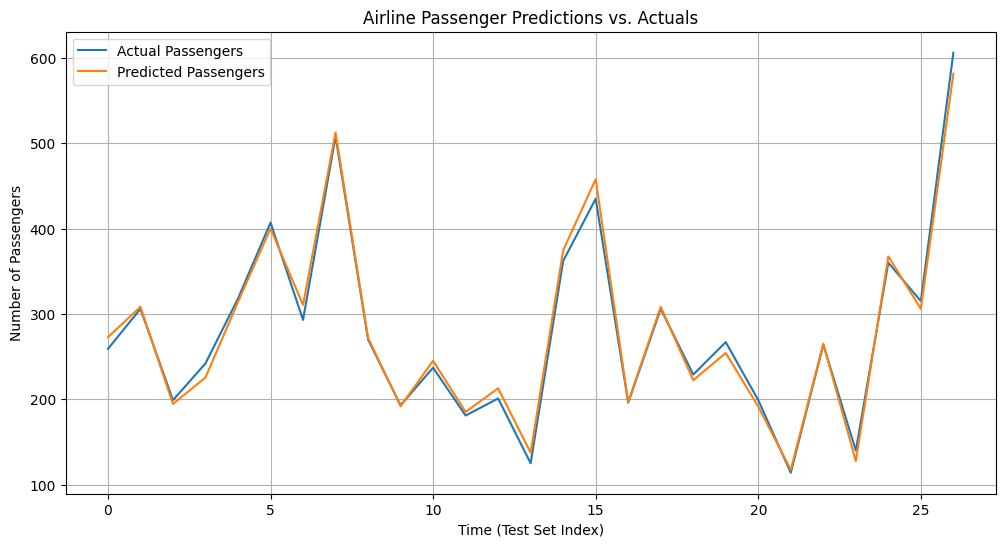

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Passengers')
plt.plot(pred, label='Predicted Passengers')
plt.title('Airline Passenger Predictions vs. Actuals')
plt.xlabel('Time (Test Set Index)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
#Now try simple implementation of LSTM

lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(50,activation="tanh",input_shape=(12,1)),
    tf.keras.layers.Dense(1)
])

lstm.compile(optimizer="adam",loss="mse")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
lstm.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test))

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - loss: 0.1289 - val_loss: 90226.8672
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0551 - val_loss: 90145.9531
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0187 - val_loss: 90062.4844
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0196 - val_loss: 90030.8047
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0238 - val_loss: 90056.9531
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0144 - val_loss: 90095.8516
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0127 - val_loss: 90119.4062
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0144 - val_loss: 90121.9453
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0140 - val_loss: 90113.7656
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0126 - val_loss: 90098.5078
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0113 - val_loss: 90086.5859
Epoch 12/100
4/4 ━━━━━━━━━━━━

In [33]:
pred_lstm = lstm.predict(x_test)
pred_lstm = scaler.inverse_transform(pred_lstm)
y_test = scaler.inverse_transform(y_test)

print(pred_lstm[0:5])
print(y_test[0:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[237.5244 ]
 [290.8349 ]
 [169.44614]
 [196.11673]
 [337.63196]]
[[1.86619053e+13]
 [2.20458004e+13]
 [1.43420391e+13]
 [1.74379432e+13]
 [2.29097736e+13]]


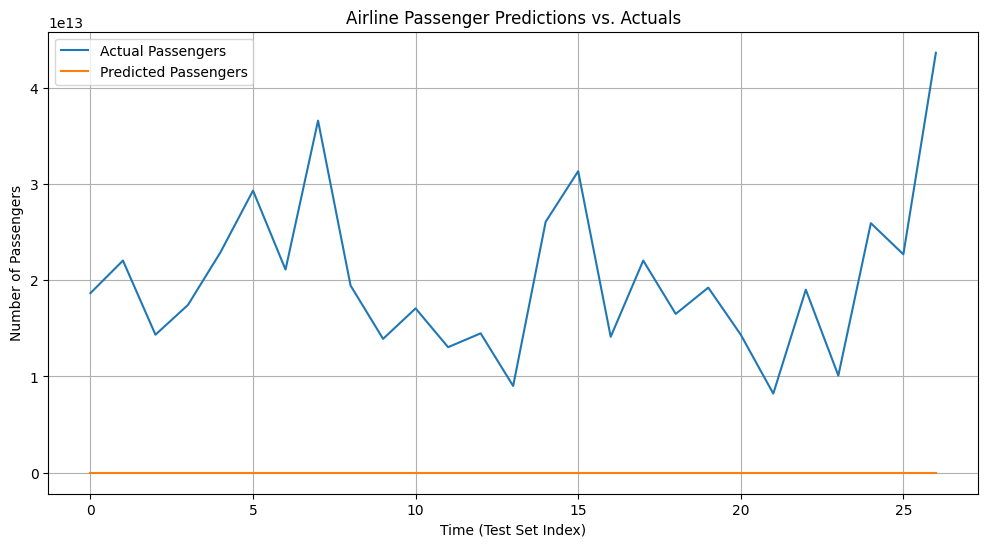

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Passengers')
plt.plot(pred_lstm, label='Predicted Passengers')
plt.title('Airline Passenger Predictions vs. Actuals')
plt.xlabel('Time (Test Set Index)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
xx , yy = create_sample(data,month=55)
xx.shape, yy.shape

((89, 55, 1), (89, 1))

In [39]:
xx_train,xx_test,yy_train,yy_test = train_test_split(xx,yy,test_size=0.2,random_state=42)

lstm.fit(xx_train,yy_train,epochs=100,validation_data=(xx_test,yy_test))

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0113 - val_loss: 0.0044
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0113 - val_loss: 0.0043
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0112 - val_loss: 0.0040
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0112 - val_loss: 0.0040
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0113 - val_loss: 0.0039
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0112 - val_loss: 0.0039
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0112 - val_loss: 0.0040
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0111 - val_loss: 0.0044
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0114 - val_loss: 0.0053
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0114 - val_loss: 0.0054
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0112 - val_loss: 0.0046
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0109 - val

In [40]:
pred_lstm = lstm.predict(xx_test)
pred_lstm = scaler.inverse_transform(pred_lstm)
yy_test = scaler.inverse_transform(yy_test)

print(pred_lstm[0:5])
print(yy_test[0:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[371.2116 ]
 [384.2633 ]
 [299.5438 ]
 [261.24658]
 [421.73322]]
[[348.]
 [340.]
 [277.]
 [293.]
 [404.]]


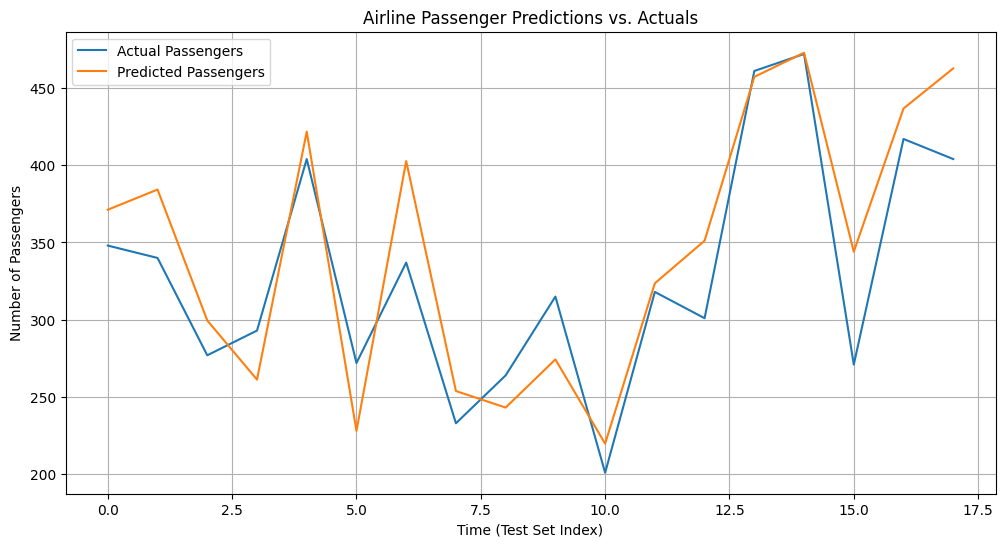

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(yy_test, label='Actual Passengers')
plt.plot(pred_lstm, label='Predicted Passengers')
plt.title('Airline Passenger Predictions vs. Actuals')
plt.xlabel('Time (Test Set Index)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()